In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PATH = "../data/processed/data_dengue_graficos.csv"

df = pd.read_csv(PATH)
df.head()


,data_inicio_semana,ano,semana_epidemiologica,casos_notificados,temperatura_media,umidade_media,taxa_reproducao_rt,nivel_alerta,nivel_alerta_desc
0,2023-12-31,2024,1,94,26.632943,69.883314,1.667024,1,Verde (Baixo)
1,2024-01-07,2024,2,104,27.225800,70.462914,1.658934,4,Vermelho (Crítico)
2,2024-01-14,2024,3,166,26.850529,74.988129,1.945857,4,Vermelho (Crítico)
3,2024-01-21,2024,4,167,24.620629,71.190843,1.439737,4,Vermelho (Crítico)
4,2024-01-28,2024,5,230,26.244271,62.834543,1.538569,4,Vermelho (Crítico)


    ano  casos_notificados
0  2024               9369
1  2025               4091
2  2026                782


/tmp/ipykernel_71265/2523787909.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


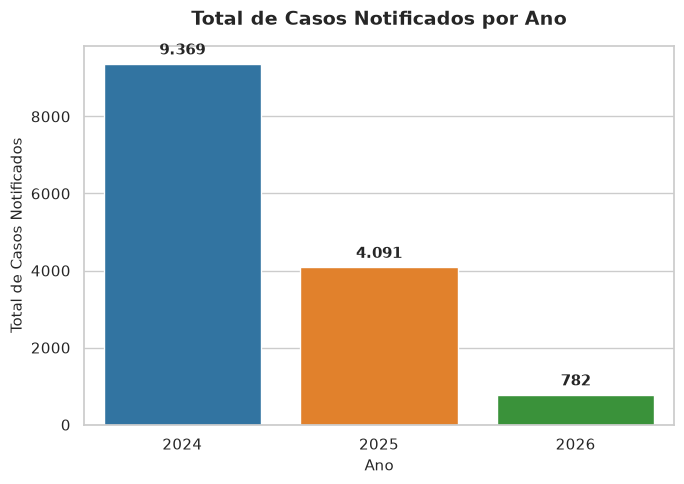

In [8]:
casos_ano = df.groupby("ano", as_index=False)["casos_notificados"].sum()

# Visualização da estrutura da tabela:
print(casos_ano)
#     ano  casos_notificados
# 0  2024               9369
# 1  2025               4091
# 2  2026                782

# 3. Configurar e apresentar o gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

cores = ["#1f77b4", "#ff7f0e", "#2ca02c"]
ax = sns.barplot(
    data=casos_ano,
    x="ano",
    y="casos_notificados",
    palette=cores
)

# 4. Adicionar os valores numéricos no topo de cada barra
for p in ax.patches:
    altura = p.get_height()
    if pd.notna(altura) and altura > 0:
        ax.annotate(
            f"{int(altura):,}".replace(",", "."),
            (p.get_x() + p.get_width() / 2.0, altura),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            xytext=(0, 4),
            textcoords="offset points",
        )

plt.title("Total de Casos Notificados por Ano", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Ano", fontsize=11)
plt.ylabel("Total de Casos Notificados", fontsize=11)
plt.tight_layout()
plt.show()

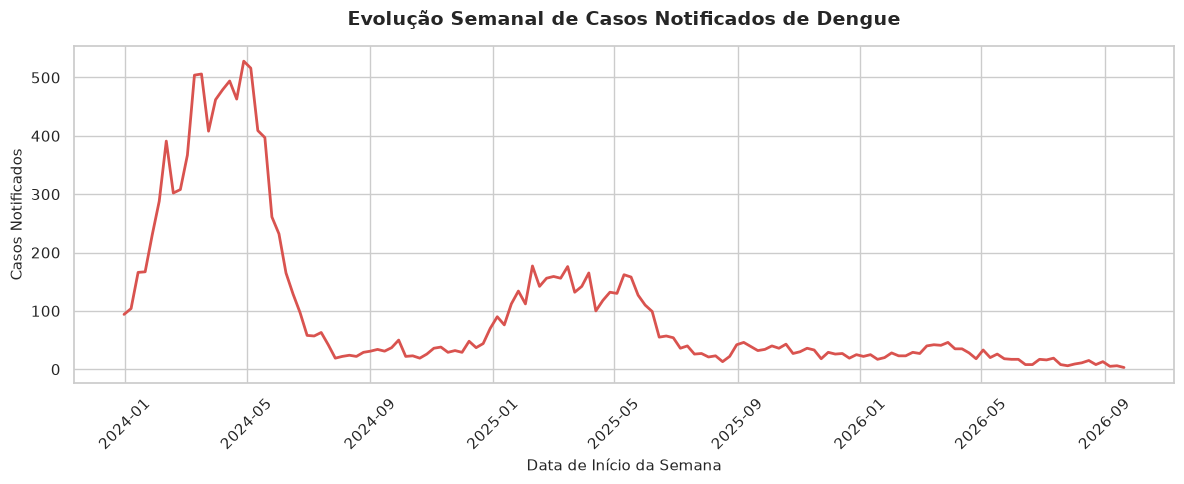

In [9]:
df["data_inicio_semana"] = pd.to_datetime(df["data_inicio_semana"])

# Configuração global de estilo
sns.set_theme(style="whitegrid")

# ==============================================================================
# Gráfico 1: Evolução Semanal Contínua (Série Temporal)
# ==============================================================================
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df,
    x="data_inicio_semana",
    y="casos_notificados",
    color="#d9534f",
    linewidth=2,
)
plt.title(
    "Evolução Semanal de Casos Notificados de Dengue",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Data de Início da Semana", fontsize=11)
plt.ylabel("Casos Notificados", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

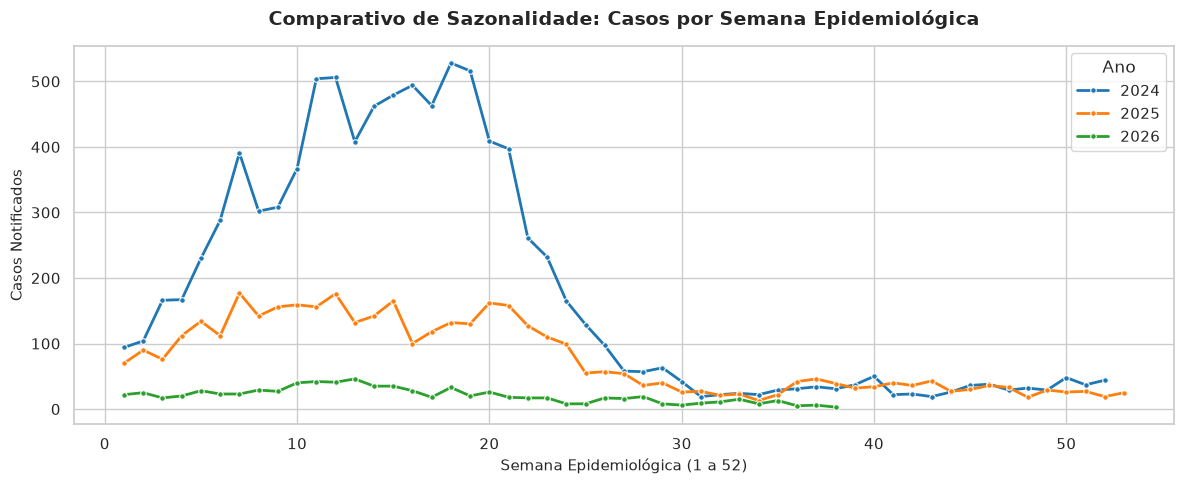

In [10]:
plt.figure(figsize=(12, 5))
cores_anos = {2024: "#1f77b4", 2025: "#ff7f0e", 2026: "#2ca02c"}

sns.lineplot(
    data=df,
    x="semana_epidemiologica",
    y="casos_notificados",
    hue="ano",
    palette=cores_anos,
    marker="o",
    markersize=4,
    linewidth=2,
)
plt.title(
    "Comparativo de Sazonalidade: Casos por Semana Epidemiológica",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Semana Epidemiológica (1 a 52)", fontsize=11)
plt.ylabel("Casos Notificados", fontsize=11)
plt.legend(title="Ano", frameon=True)
plt.tight_layout()
plt.show()

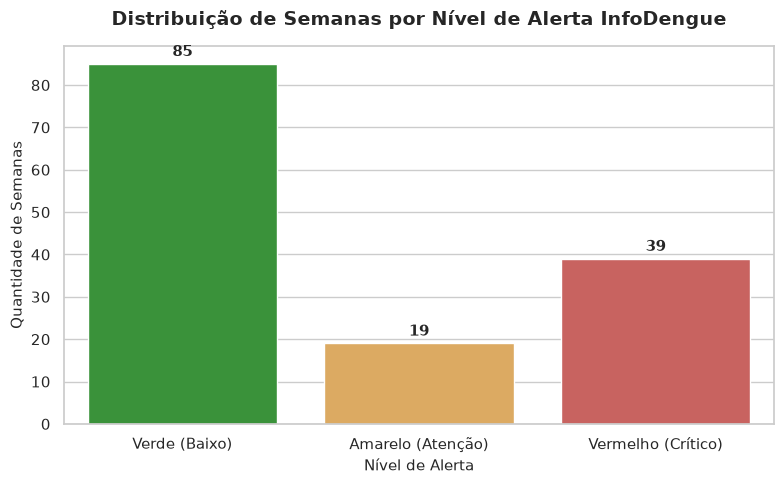

In [11]:
plt.figure(figsize=(8, 5))

# Ordem epidemiológica esperada e paleta semântica
ordem_niveis = [
    "Verde (Baixo)",
    "Amarelo (Atenção)",
    "Laranja (Alerta)",
    "Vermelho (Crítico)",
]
ordem_presente = [
    n for n in ordem_niveis if n in df["nivel_alerta_desc"].unique()
]
cores_alerta = {
    "Verde (Baixo)": "#2ca02c",
    "Amarelo (Atenção)": "#f0ad4e",
    "Laranja (Alerta)": "#ff7f0e",
    "Vermelho (Crítico)": "#d9534f",
}

ax = sns.countplot(
    data=df,
    x="nivel_alerta_desc",
    order=ordem_presente,
    palette=cores_alerta,
    hue="nivel_alerta_desc",
    legend=False,
)

# Adicionar o total numérico em cima de cada barra
for p in ax.patches:
    altura = int(p.get_height())
    if altura > 0:
        ax.annotate(
            f"{altura}",
            (p.get_x() + p.get_width() / 2.0, altura),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            xytext=(0, 3),
            textcoords="offset points",
        )

plt.title(
    "Distribuição de Semanas por Nível de Alerta InfoDengue",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Nível de Alerta", fontsize=11)
plt.ylabel("Quantidade de Semanas", fontsize=11)
plt.tight_layout()
plt.show()


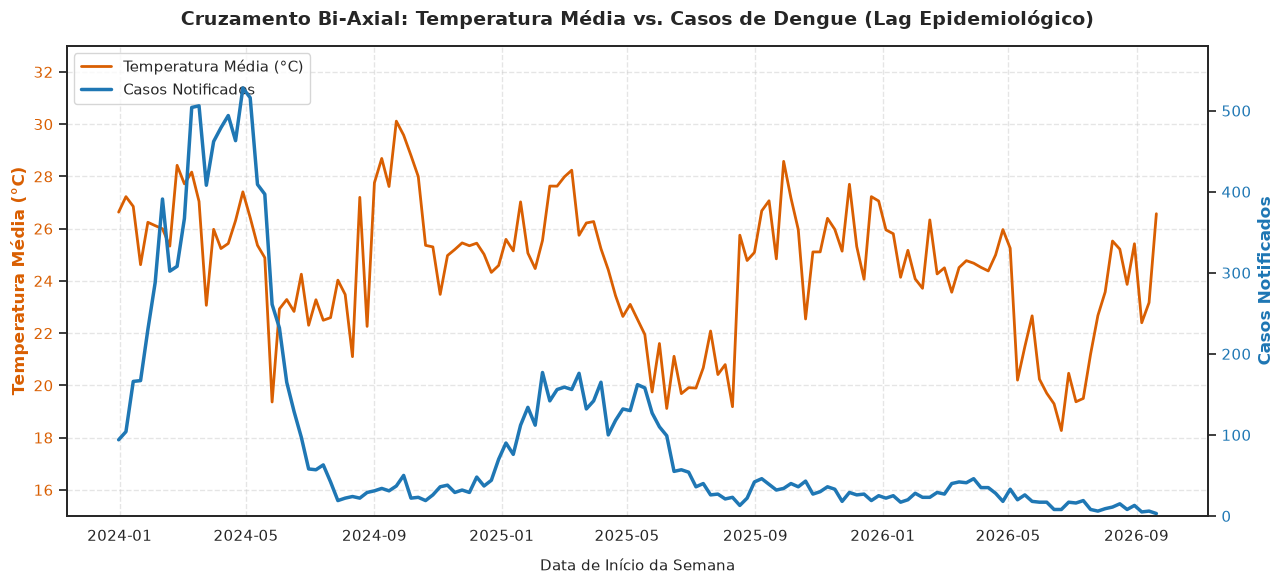

In [14]:
df = df.sort_values("data_inicio_semana").reset_index(drop=True)

# 3. Configuração do layout
sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(13, 6))

cor_temp = "#d95f02"  # Laranja (temperatura)
cor_casos = "#1f77b4"  # Azul (casos)

# --- EIXO Y1 (Esquerdo): Temperatura Média ---
linha1 = ax1.plot(
    df["data_inicio_semana"],
    df["temperatura_media"],
    color=cor_temp,
    linewidth=2,
    label="Temperatura Média (°C)",
)
ax1.set_xlabel("Data de Início da Semana", fontsize=11, labelpad=10)
ax1.set_ylabel(
    "Temperatura Média (°C)", color=cor_temp, fontsize=12, fontweight="bold"
)
ax1.tick_params(axis="y", labelcolor=cor_temp)
ax1.set_ylim(15, 33)
ax1.grid(True, linestyle="--", alpha=0.5)

# --- EIXO Y2 (Direito): Casos Notificados ---
ax2 = ax1.twinx()
linha2 = ax2.plot(
    df["data_inicio_semana"],
    df["casos_notificados"],
    color=cor_casos,
    linewidth=2.5,
    label="Casos Notificados",
)
ax2.set_ylabel(
    "Casos Notificados", color=cor_casos, fontsize=12, fontweight="bold"
)
ax2.tick_params(axis="y", labelcolor=cor_casos)
ax2.set_ylim(0, 580)
ax2.grid(False)  # Mantém desligado para não poluir a grade do eixo 1

# 4. Legenda combinada no canto superior esquerdo
linhas = linha1 + linha2
labels = [l.get_label() for l in linhas]
ax1.legend(linhas, labels, loc="upper left", frameon=True)

plt.title(
    "Cruzamento Bi-Axial: Temperatura Média vs. Casos de Dengue (Lag"
    " Epidemiológico)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()